In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Parameter Ambang Batas (Disarankan oleh Jurnal Yao et al.)
# Ambang batas Otsu dimodifikasi dengan nilai ini
THRESHOLD_MODIFICATION = 10 
MIN_AREA_THRESHOLD = 1000 # Ambang batas area minimum untuk menghilangkan noise kecil (piksel)

In [116]:
def segment_leaf_from_background(img_bgr):
    # 1. Konversi ke HSV untuk memisahkan warna dari intensitas cahaya
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    img_h = img_hsv[:, :, 0]  # Channel Hue
    # 2. Definisikan Rentang Warna (Peringatan: Angka ini WAJIB dikalibrasi!)
    # Rentang untuk klorofil daun sehat (Hijau)
    lower_green = np.array([35, 85, 40])
    upper_green = np.array([85, 255, 200])
    mask_green = cv2.inRange(img_hsv, lower_green, upper_green)

    # Rentang untuk lesi penyakit (Kuning/Jingga/Coklat Terang untuk Tungro, Blas, Hawar)
    # Batas bawah Saturation (50) dan Value (50) ditujukan agar lumpur gelap tidak terdeteksi
    lower_disease = np.array([10, 100, 120])
    upper_disease = np.array([34, 255, 255])
    mask_disease = cv2.inRange(img_hsv, lower_disease, upper_disease)

    # 3. Gabungkan Mask (Daun Hijau + Lesi Penyakit)
    mask_combined = cv2.bitwise_or(mask_green, mask_disease)

    # 4. Operasi Morfologi (Closing)
    # Menutup lubang kecil (noise) di dalam daun menggunakan kernel elips
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask_cleaned = cv2.morphologyEx(mask_combined, cv2.MORPH_CLOSE, kernel, iterations=1)

    # 5. Deteksi Kontur Terbesar (Asumsi: Daun adalah objek terbesar di gambar)
    contours, _ = cv2.findContours(mask_cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        # Jika gagal menemukan objek, kembalikan gambar asli (fail-safe)
        return img_bgr, np.zeros_like(img_h)

    # Ambil kontur dengan area paling besar
    largest_contour = max(contours, key=cv2.contourArea)

    # 6. Membuat Masking Solid (Mengisi lubang penyakit di dalam daun)
    final_mask = np.zeros_like(img_h)
    # cv2.FILLED memastikan lesi penyakit (yang mungkin bolong di binary_mask) ikut terisi
    cv2.drawContours(final_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)

    # 7. Menerapkan Masking ke Gambar Asli
    # Semua latar belakang akan menjadi piksel dengan nilai [0, 0, 0] (Hitam)
    
        # (Opsional tapi direkomendasikan): Ekstraksi kontur terbesar untuk membuang gulma di latar belakang
    # ...

    # 8. Terapkan Masking ke citra asli
    segmented_bgr = cv2.bitwise_and(img_bgr, img_bgr, mask=final_mask)
    # segmented_bgr = cv2.bitwise_and(img_bgr, img_bgr, mask=mask_combined)

    # 9. Konversi ke RGB untuk visualisasi yang benar (Mencegah daun terlihat kebiruan)
    segmented_rgb = cv2.cvtColor(segmented_bgr, cv2.COLOR_BGR2RGB)

    # return segmented_rgb, final_mask
    return segmented_rgb

Text(0.5, 1.0, 'B Channel')

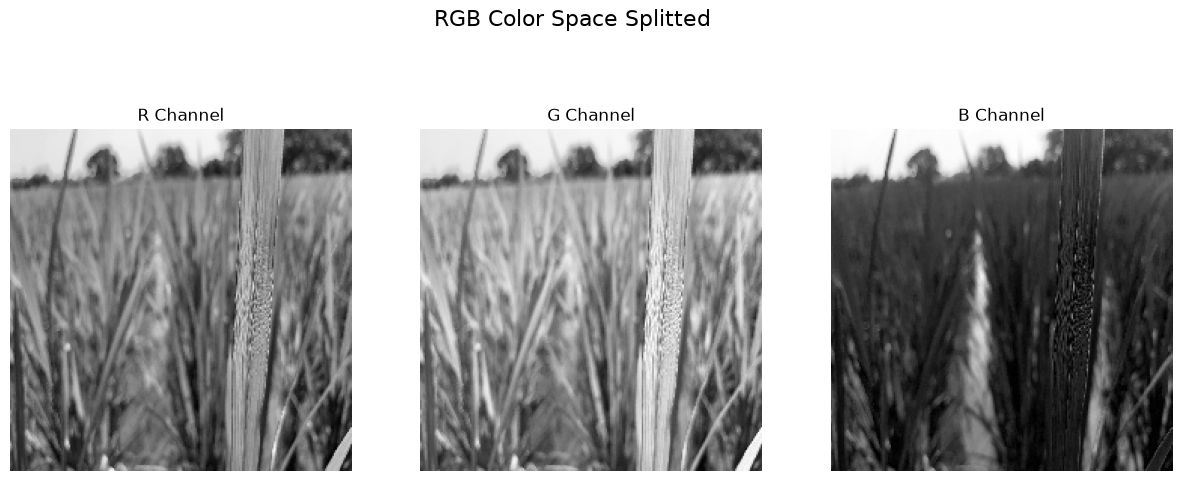

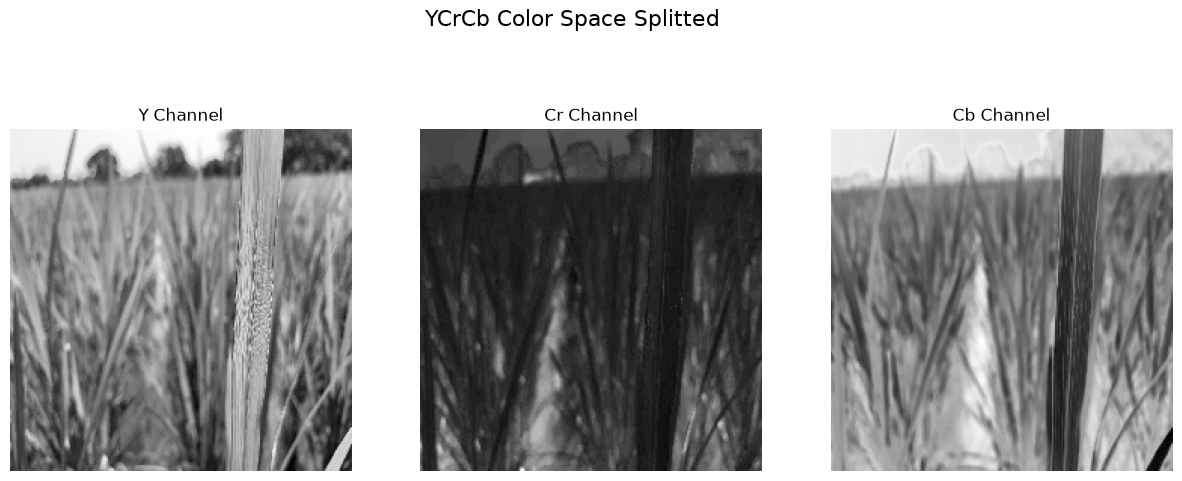

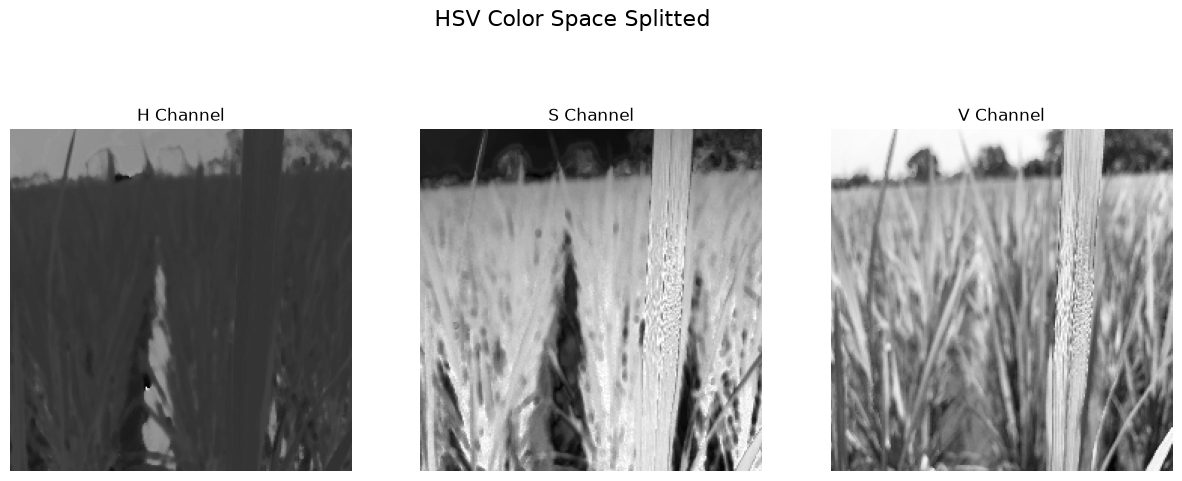

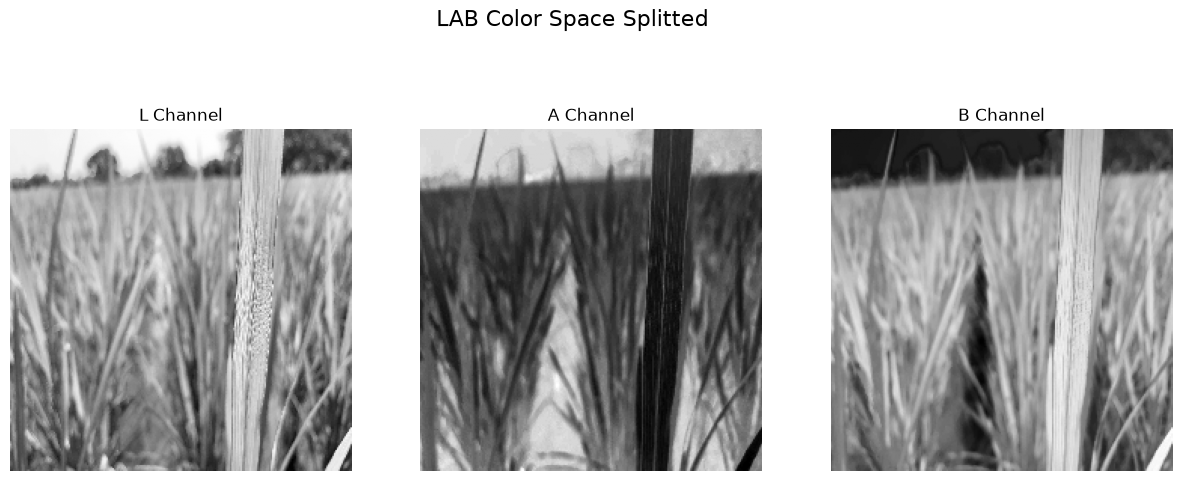

In [120]:
IMG_SIZE = (227, 227)
label = 'normal'
img = cv2.resize(cv2.imread('D:/Backup Mario/Coding Room/Rice_Disease/datasets/Malba_test_images/normal/IMG_5365.JPG'), IMG_SIZE)

fig = plt.figure(figsize=(15, 6))

fig.suptitle('RGB Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("R Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("G Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("B Channel")

fig = plt.figure(figsize=(15, 6))

fig.suptitle('YCrCb Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("Y Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("Cr Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("Cb Channel")

fig = plt.figure(figsize=(15, 6))

fig.suptitle('HSV Color Space Splitted', fontsize=16)

low = 0;
high = 180;
img_h = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,0] - low;
img_h =img_h/(high - low);

fig.add_subplot(1, 3, 1)
plt.imshow(img_h, cmap='gray')
plt.axis('off') 
plt.title("H Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("S Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2HSV)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("V Channel")

fig = plt.figure(figsize=(15, 6))

fig.suptitle('LAB Color Space Splitted', fontsize=16)

fig.add_subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:,:,0], cmap='gray')
plt.axis('off') 
plt.title("L Channel")

fig.add_subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:,:,1], cmap='gray')
plt.axis('off') 
plt.title("A Channel")

fig.add_subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2LAB)[:,:,2], cmap='gray')
plt.axis('off') 
plt.title("B Channel")

(227, 227, 3)


Text(0.5, 1.0, 'normal')

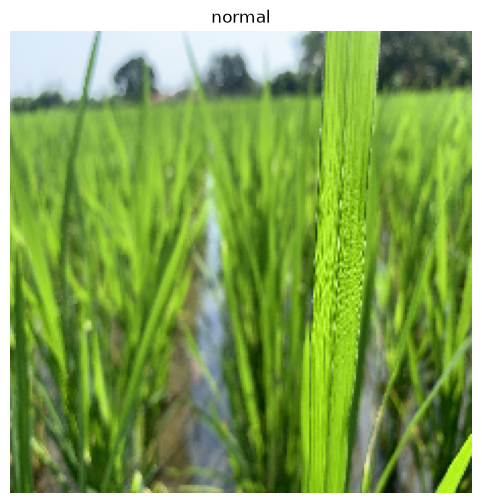

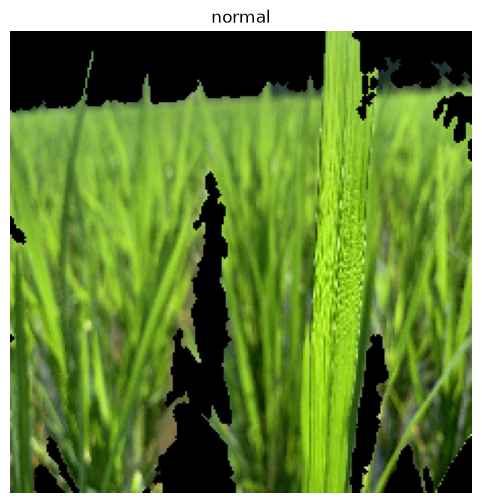

In [121]:
print(img.shape)
segmented_image = segment_leaf_from_background(img)

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(segmented_image)
plt.axis('off') 
plt.title(label)

(227, 227, 3)


Text(0.5, 1.0, 'brown_spot')

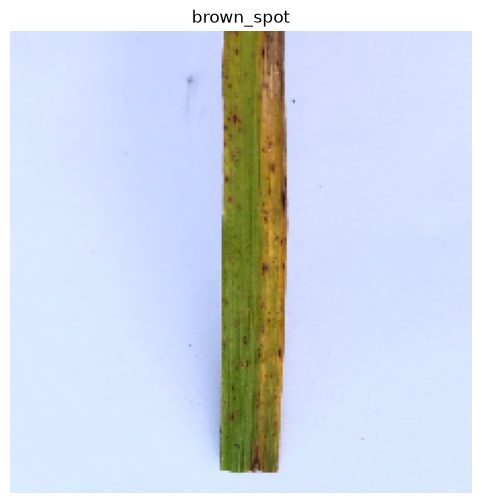

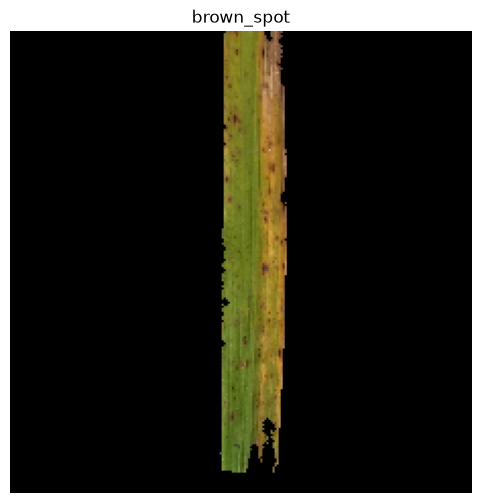

In [122]:
IMG_SIZE = (227, 227)
label = 'brown_spot'
img = cv2.resize(cv2.imread('datasets/leaf-rice-disease-indonesia/tungro/IMG_0872.jpg'), IMG_SIZE)
print(img.shape)
segment_image2 = segment_leaf_from_background(img)

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(segment_image2, cmap='gray')
plt.axis('off') 
plt.title(label)